In [1]:
import pandas as pd  
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline
sns.set_style("darkgrid")

In [2]:
df = pd.read_csv('My Uber Drives - 2016.csv')

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [3]:
# Rename columns (clean names)
df.columns = ['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES', 'PURPOSE']

# Convert to datetime
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors='coerce')
df['END_DATE'] = pd.to_datetime(df['END_DATE'], errors='coerce')

# Remove duplicates
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

# Remove invalid trips (duration = 0 but miles > 0)
df = df[(df['END_DATE'] > df['START_DATE'])]

# Create NEW feature (VERY IMPORTANT 🔥)
df['DURATION_MIN'] = (df['END_DATE'] - df['START_DATE']).dt.total_seconds() / 60

# Extract useful time features (UNIQUE ADD 🔥)
df['HOUR'] = df['START_DATE'].dt.hour
df['DAY'] = df['START_DATE'].dt.day_name()
df['MONTH'] = df['START_DATE'].dt.month

df.head()

Duplicates before: 1


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DURATION_MIN,HOUR,DAY,MONTH
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,6.0,21,Friday,1
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN,12.0,1,Saturday,1
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,13.0,20,Saturday,1
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,14.0,17,Tuesday,1
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,67.0,14,Wednesday,1


VISUALIZATION

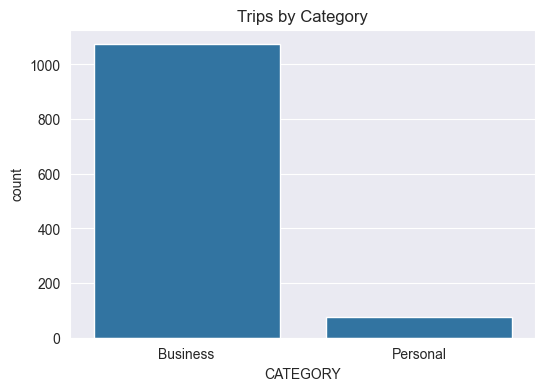

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='CATEGORY', data=df)
plt.title("Trips by Category")
plt.show()

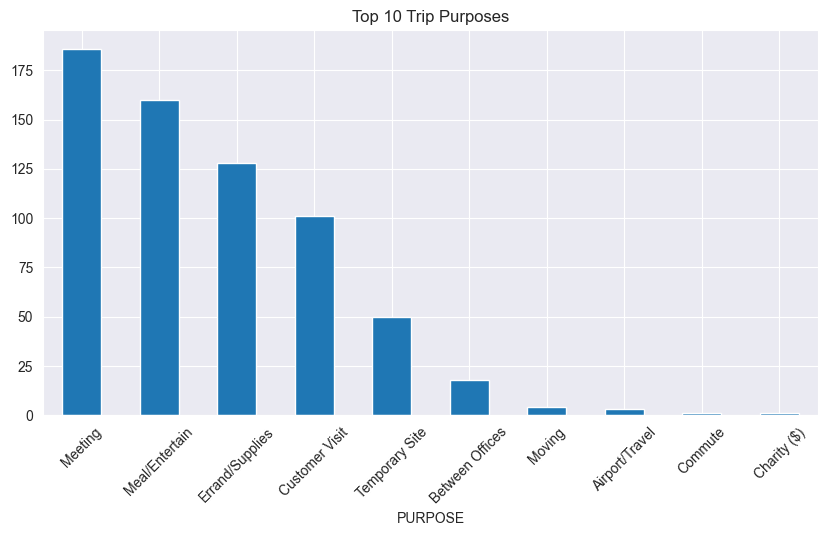

In [5]:
plt.figure(figsize=(10,5))
df['PURPOSE'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Trip Purposes")
plt.xticks(rotation=45)
plt.show()

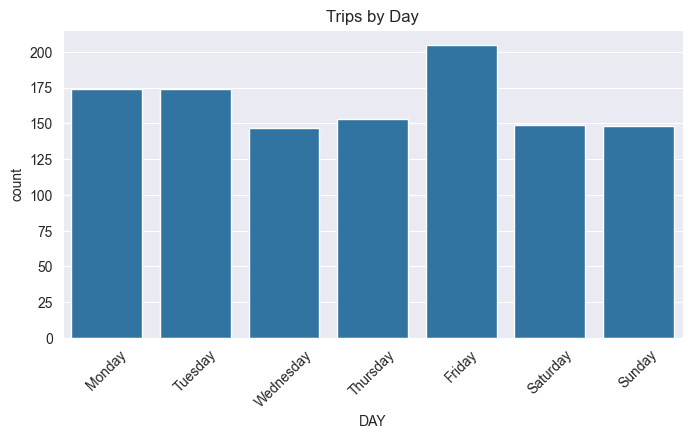

In [6]:
plt.figure(figsize=(8,4))
sns.countplot(x='DAY', data=df,
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Trips by Day")
plt.xticks(rotation=45)
plt.show()

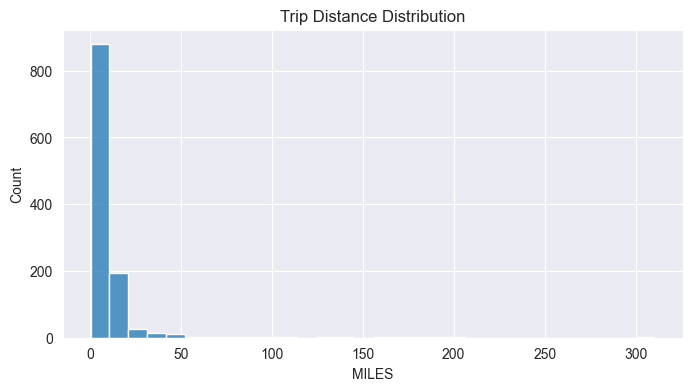

In [7]:
plt.figure(figsize=(8,4))
sns.histplot(df['MILES'], bins=30)
plt.title("Trip Distance Distribution")
plt.show()

In [8]:
print("🔍 KEY INSIGHTS:")

print("\n1. Most trips belong to:", df['CATEGORY'].mode()[0])

print("\n2. Most common trip purpose:", df['PURPOSE'].mode()[0])

print("\n3. Peak trip hour:", df['HOUR'].mode()[0])

print("\n4. Most active day:", df['DAY'].mode()[0])

print("\n5. Average trip distance:", round(df['MILES'].mean(),2), "miles")

print("\n6. Average trip duration:", round(df['DURATION_MIN'].mean(),2), "minutes")

🔍 KEY INSIGHTS:

1. Most trips belong to: Business

2. Most common trip purpose: Meeting

3. Peak trip hour: 15

4. Most active day: Friday

5. Average trip distance: 10.54 miles

6. Average trip duration: 23.32 minutes


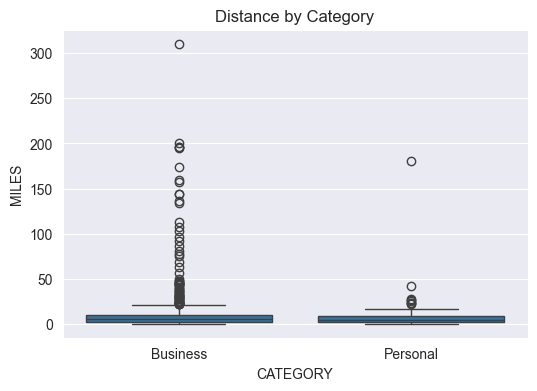

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x='CATEGORY', y='MILES', data=df)
plt.title("Distance by Category")
plt.show()

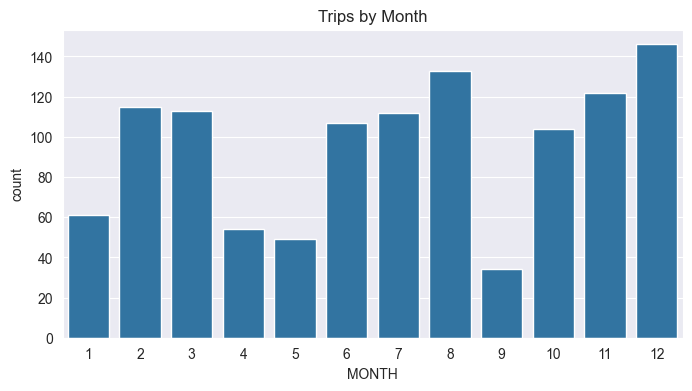

In [10]:
plt.figure(figsize=(8,4))
sns.countplot(x='MONTH', data=df)
plt.title("Trips by Month")
plt.show()

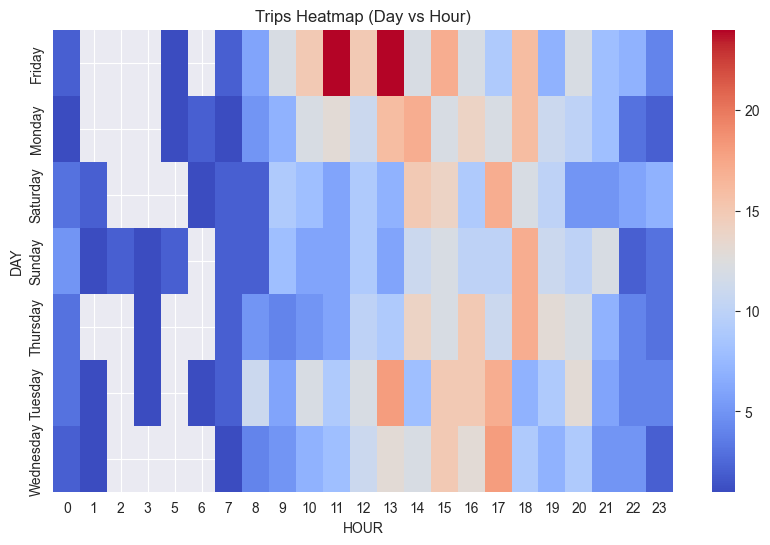

In [11]:
pivot = df.pivot_table(index='DAY', columns='HOUR', values='MILES', aggfunc='count')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Trips Heatmap (Day vs Hour)")
plt.show()

In [12]:
'''columns in dataset '''
df.columns

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE', 'DURATION_MIN', 'HOUR', 'DAY', 'MONTH'],
      dtype='object')

In [13]:
df.shape

(1150, 11)

In [14]:
'''checking null values in dataset '''
df.isnull().sum()

START_DATE        0
END_DATE          0
CATEGORY          0
START             0
STOP              0
MILES             0
PURPOSE         498
DURATION_MIN      0
HOUR              0
DAY               0
MONTH             0
dtype: int64

In [15]:
"""find duplicate rows"""
df[df.duplicated()]

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DURATION_MIN,HOUR,DAY,MONTH


In [16]:
## there is one duplicated row, we are gonna remove this duplicate row
df.drop_duplicates(inplace=True)

In [17]:
'''There we have 4 rows having starting and end-time exactly equal i.e. zero trip time, 
while having non-zero miles (distance) - which cannot be possible.'''

df.drop(df.index[[751, 761, 798, 807]], inplace=True)

In [19]:
''' Converting START_DATE and END_DATE into date time'''

df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors='coerce')
df['END_DATE'] = pd.to_datetime(df['END_DATE'], errors='coerce')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1146 entries, 0 to 1154
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   START_DATE    1146 non-null   datetime64[ns]
 1   END_DATE      1146 non-null   datetime64[ns]
 2   CATEGORY      1146 non-null   object        
 3   START         1146 non-null   object        
 4   STOP          1146 non-null   object        
 5   MILES         1146 non-null   float64       
 6   PURPOSE       652 non-null    object        
 7   DURATION_MIN  1146 non-null   float64       
 8   HOUR          1146 non-null   int32         
 9   DAY           1146 non-null   object        
 10  MONTH         1146 non-null   int32         
dtypes: datetime64[ns](2), float64(2), int32(2), object(5)
memory usage: 98.5+ KB


In [21]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DURATION_MIN,HOUR,DAY,MONTH
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,6.0,21,Friday,1
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN,12.0,1,Saturday,1
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,13.0,20,Saturday,1
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,14.0,17,Tuesday,1
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,67.0,14,Wednesday,1


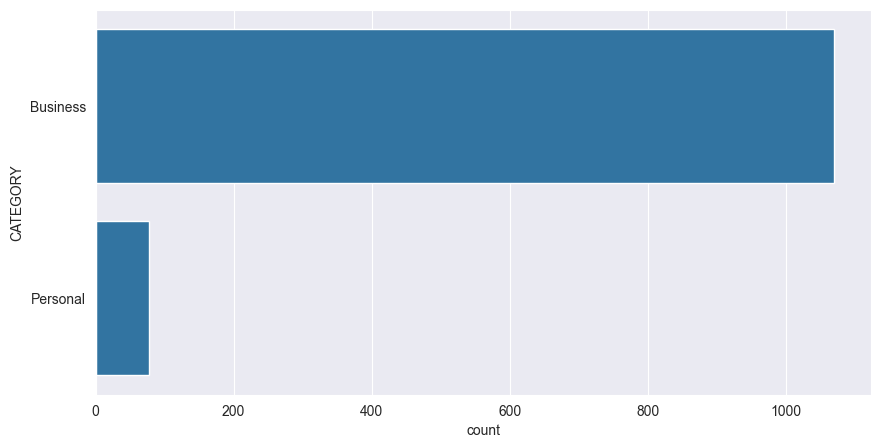

In [22]:
''' Count Plot '''
plt.figure(figsize=(10, 5))
sns.countplot(df['CATEGORY']);

In [46]:
start_labels = df.START.value_counts().nlargest(10)

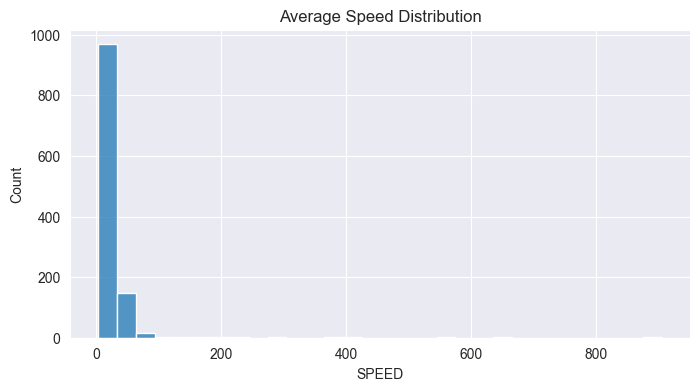

In [26]:
# Speed = Distance / Time
df['SPEED'] = df['MILES'] / (df['DURATION_MIN'] / 60)

plt.figure(figsize=(8,4))
sns.histplot(df['SPEED'], bins=30)
plt.title("Average Speed Distribution")
plt.show()

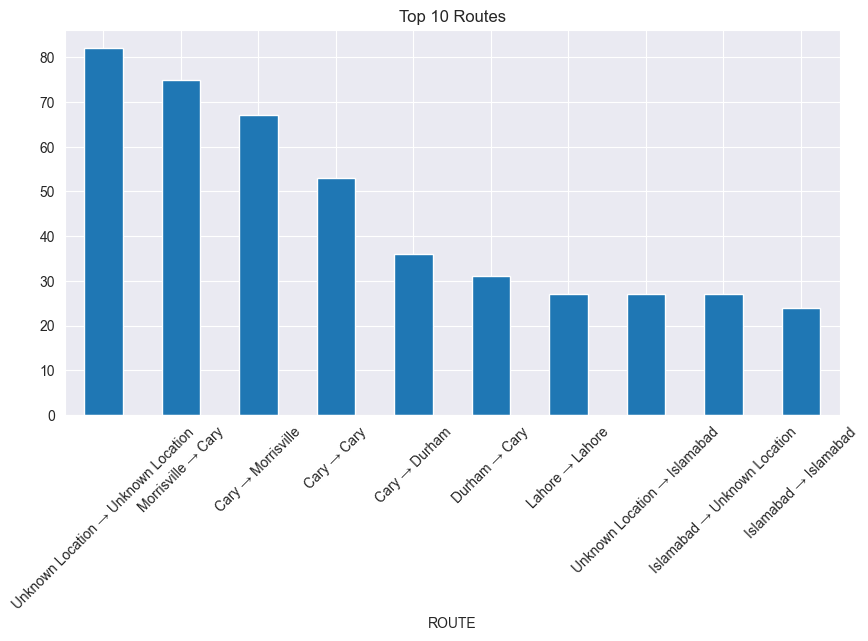

In [28]:
# Create route column
df['ROUTE'] = df['START'] + " → " + df['STOP']

top_routes = df['ROUTE'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_routes.plot(kind='bar')
plt.title("Top 10 Routes")
plt.xticks(rotation=45)
plt.show()

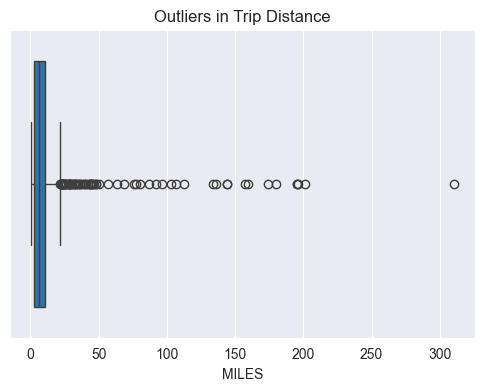

In [30]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['MILES'])
plt.title("Outliers in Trip Distance")
plt.show()

In [31]:
df.MONTH.unique()

array(['Jan', 'Feb', 'Mar', 'April', 'May', 'June', 'July', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec'], dtype=object)

In [68]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,MONTH
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,Jan
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN,Jan
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,Jan
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,Jan
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,Jan


In [33]:
''' creating a dictonary that contains info about miles column '''
miles_dic = {}

for i in df.MILES:
    if i < 10:
        if '0-10 miles' not in miles_dic:
            miles_dic['0-10 miles'] = [i]
        else:
            miles_dic['0-10 miles'].append(i)
            
    elif i >= 10 and i < 20:
        if '10-20 miles' not in miles_dic:
            miles_dic['10-20 miles'] = [i]
        else:
            miles_dic['10-20 miles'].append(i)
            
    elif i >= 20 and i < 30:
        if '20-30 miles' not in miles_dic:
            miles_dic['20-30 miles'] = [i]
        else:
            miles_dic['20-30 miles'].append(i)
            
    elif i >= 30 and i < 40:
        if '30-40 miles' not in miles_dic:
            miles_dic['30-40 miles'] = [i]
        else:
            miles_dic['30-40 miles'].append(i)
            
    elif i >= 40 and i < 50:
        if '40-50 miles' not in miles_dic:
            miles_dic['40-50 miles'] = [i]
        else:
            miles_dic['40-50 miles'].append(i)
    else:
        if 'Above 50 miles' not in miles_dic:
            miles_dic['Above 50 miles'] = [i]
        else:
            miles_dic['Above 50 miles'].append(i)

In [34]:
len_miles = []
for key in miles_dic:
    len_miles.append((key, len(miles_dic[key])))

In [36]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DURATION_MIN,HOUR,DAY,MONTH,SPEED,ROUTE
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,6.0,21,Friday,Jan,51.000000,Fort Pierce → Fort Pierce
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN,12.0,1,Saturday,Jan,25.000000,Fort Pierce → Fort Pierce
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,13.0,20,Saturday,Jan,22.153846,Fort Pierce → Fort Pierce
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,14.0,17,Tuesday,Jan,20.142857,Fort Pierce → Fort Pierce
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,67.0,14,Wednesday,Jan,57.044776,Fort Pierce → West Palm Beach


In [37]:
''' Now we want to know how many trips were made on Day time and how many on Night time '''
t = pd.to_datetime(['18:00:00']).time

In [38]:
def check_time(tim):
    if t > tim:
        tim = 'DAY RIDE'
    else:
        tim = 'NIGHT RIDE'
    
df['DAY/NIGHT'] = df.apply(lambda x : 'NIGHT RIDE' if x['START_DATE'].time() > t else 'DAY RIDE', axis=1)

In [40]:
df['DAY'] = df.START_DATE.dt.weekday

In [41]:
day_label = {
    0: 'Mon', 1: 'Tues', 2: 'Wed', 3: 'Thus', 4: 'Fir', 5: 'Sat', 6: 'Sun'
}
df['DAY'] = df['DAY'].map(day_label)

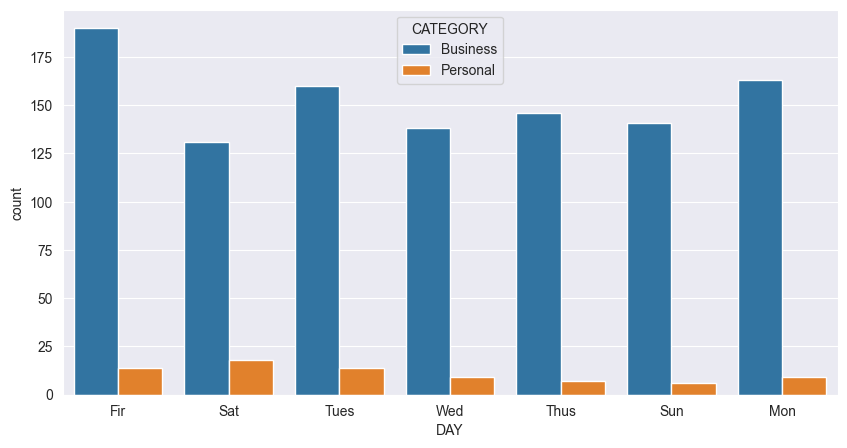

In [43]:
''' count plot of day'''
plt.figure(figsize=(10, 5))
sns.countplot(hue='CATEGORY', x='DAY', data=df);

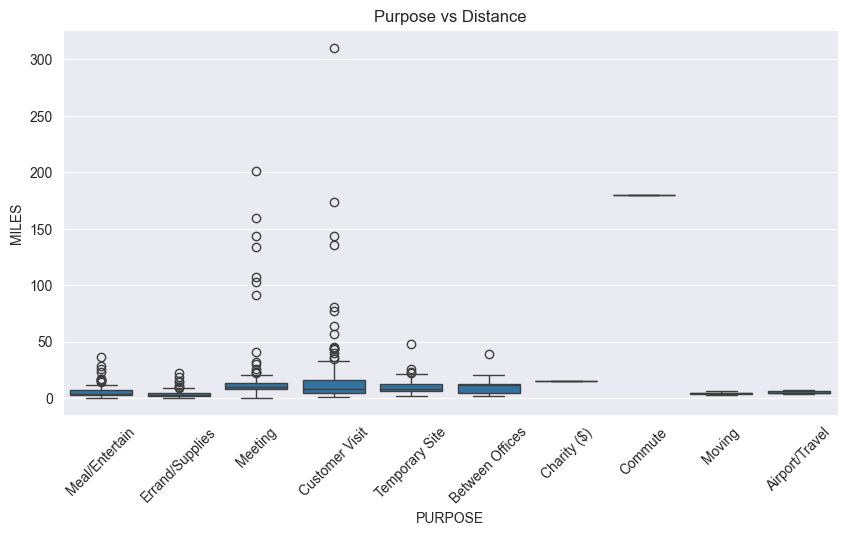

In [44]:
plt.figure(figsize=(10,5))
sns.boxplot(x='PURPOSE', y='MILES', data=df)
plt.xticks(rotation=45)
plt.title("Purpose vs Distance")
plt.show()